<a href="https://colab.research.google.com/github/xyhosino/Machine_Learning/blob/main/%E6%9C%BA%E5%99%A8%E5%AD%A6%E4%B9%A0_%E7%AC%AC6%E8%AF%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")

print("Path to dataset files:", path)

100%|██████████| 750M/750M [00:09<00:00, 85.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jessicali9530/stanford-dogs-dataset/versions/2


In [2]:
import os

# 列出下载目录下的所有文件
print(os.listdir(path))

# 如果你想在左侧文件栏直接看到它，可以创建一个“软链接”到 /content
!ln -s {path} /content/stanford_dogs

['annotations', 'images']


In [3]:
import numpy as np
import pandas as pd
print(os.listdir('/content/stanford_dogs/images/Images'))

['n02105641-Old_English_sheepdog', 'n02110185-Siberian_husky', 'n02089078-black-and-tan_coonhound', 'n02091244-Ibizan_hound', 'n02086646-Blenheim_spaniel', 'n02107683-Bernese_mountain_dog', 'n02096294-Australian_terrier', 'n02113799-standard_poodle', 'n02111500-Great_Pyrenees', 'n02110627-affenpinscher', 'n02093991-Irish_terrier', 'n02093859-Kerry_blue_terrier', 'n02113186-Cardigan', 'n02088094-Afghan_hound', 'n02088238-basset', 'n02113624-toy_poodle', 'n02096437-Dandie_Dinmont', 'n02106030-collie', 'n02091467-Norwegian_elkhound', 'n02102973-Irish_water_spaniel', 'n02099712-Labrador_retriever', 'n02094433-Yorkshire_terrier', 'n02091831-Saluki', 'n02088466-bloodhound', 'n02104029-kuvasz', 'n02112350-keeshond', 'n02105855-Shetland_sheepdog', 'n02107574-Greater_Swiss_Mountain_dog', 'n02108915-French_bulldog', 'n02105162-malinois', 'n02086910-papillon', 'n02085782-Japanese_spaniel', 'n02108422-bull_mastiff', 'n02098105-soft-coated_wheaten_terrier', 'n02086240-Shih-Tzu', 'n02104365-schipper

In [4]:
# 本示例只处理这10种狗
dir = '/content/stanford_dogs/images/Images/'
chihuahua_dir = dir+'n02085620-Chihuahua' #吉娃娃 =chihuahua_dir = os.path.join(dir, 'n02085620-Chihuahua')
japanese_spaniel_dir = dir+'n02085782-Japanese_spaniel' #日本狆
maltese_dir = dir+'n02085936-Maltese_dog' #马尔济斯犬
pekinese_dir = dir+'n02086079-Pekinese' #北京狮子狗
shitzu_dir = dir+'n02086240-Shih-Tzu' #西施犬
blenheim_spaniel_dir = dir+'n02086646-Blenheim_spaniel' #英国可卡犬
papillon_dir = dir+'n02086910-papillon' #蝴蝶犬
toy_terrier_dir = dir+'n02087046-toy_terrier' #玩具猎狐梗
afghan_hound_dir = dir+'n02088094-Afghan_hound' #阿富汗猎犬
basset_dir = dir+'n02088238-basset' #巴吉度猎犬

In [5]:
import cv2 # 导入Open CV工具箱
X = []
y_label = []
imgsize = 150
# 定义一个函数读入狗狗图片
def training_data(label,data_dir):
    print ("正在读入：", data_dir)
    for img in os.listdir(data_dir): #遍历该目录下所有的文件名
        path = os.path.join(data_dir,img) #把“文件夹路径 + 文件名”拼成完整路径
        img = cv2.imread(path,cv2.IMREAD_COLOR) #用OpenCV读取图片，以彩色模式读取（3通道BGR）
        img = cv2.resize(img,(imgsize,imgsize)) #统一图片规格
        X.append(np.array(img))
        y_label.append(str(label)) #str()转为字符串
# 读入10个目录中的狗狗图片
training_data('chihuahua',chihuahua_dir)
training_data('japanese_spaniel',japanese_spaniel_dir)
training_data('maltese',maltese_dir)
training_data('pekinese',pekinese_dir)
training_data('shitzu',shitzu_dir)
training_data('blenheim_spaniel',blenheim_spaniel_dir)
training_data('papillon',papillon_dir)
training_data('toy_terrier',toy_terrier_dir)
training_data('afghan_hound',afghan_hound_dir)
training_data('basset',basset_dir)

正在读入： /content/stanford_dogs/images/Images/n02085620-Chihuahua
正在读入： /content/stanford_dogs/images/Images/n02085782-Japanese_spaniel
正在读入： /content/stanford_dogs/images/Images/n02085936-Maltese_dog
正在读入： /content/stanford_dogs/images/Images/n02086079-Pekinese
正在读入： /content/stanford_dogs/images/Images/n02086240-Shih-Tzu
正在读入： /content/stanford_dogs/images/Images/n02086646-Blenheim_spaniel
正在读入： /content/stanford_dogs/images/Images/n02086910-papillon
正在读入： /content/stanford_dogs/images/Images/n02087046-toy_terrier
正在读入： /content/stanford_dogs/images/Images/n02088094-Afghan_hound
正在读入： /content/stanford_dogs/images/Images/n02088238-basset


In [6]:
from sklearn.preprocessing import LabelEncoder # 导入标签编码工具
from tensorflow.keras.utils import to_categorical # 导入One-hot编码工具
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_label) # 标签编码
y = to_categorical(y,10) # 将标签转换为One-hot编码
X = np.array(X) # 将X从列表转换为张量数组
X = X/255 # 将X张量归一化

In [7]:
print ('X张量的形状：', X.shape)
print ('X张量的第一个数据：', X[1])

X张量的形状： (1922, 150, 150, 3)
X张量的第一个数据： [[[0.03137255 0.04705882 0.02352941]
  [0.02352941 0.03921569 0.01568627]
  [0.01176471 0.02745098 0.00392157]
  ...
  [0.18039216 0.21568627 0.14509804]
  [0.28627451 0.25490196 0.09019608]
  [0.36862745 0.28235294 0.06666667]]

 [[0.05882353 0.0745098  0.05098039]
  [0.05490196 0.07058824 0.04705882]
  [0.05098039 0.06666667 0.04313725]
  ...
  [0.15686275 0.23921569 0.21176471]
  [0.20392157 0.23921569 0.1254902 ]
  [0.31372549 0.27058824 0.08235294]]

 [[0.09019608 0.10588235 0.08235294]
  [0.09411765 0.10980392 0.08627451]
  [0.09019608 0.10588235 0.08235294]
  ...
  [0.09019608 0.22745098 0.25882353]
  [0.12941176 0.24705882 0.22352941]
  [0.23529412 0.29019608 0.18431373]]

 ...

 [[0.01176471 0.02745098 0.00784314]
  [0.01568627 0.03137255 0.01176471]
  [0.01960784 0.03529412 0.01568627]
  ...
  [0.01176471 0.02745098 0.00784314]
  [0.01176471 0.02745098 0.00784314]
  [0.00392157 0.01960784 0.        ]]

 [[0.00392157 0.01960784 0.        

In [8]:
print ('y张量的形状：', y.shape)
print ('y张量的第一个数据：', y[1])

y张量的形状： (1922, 10)
y张量的第一个数据： [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


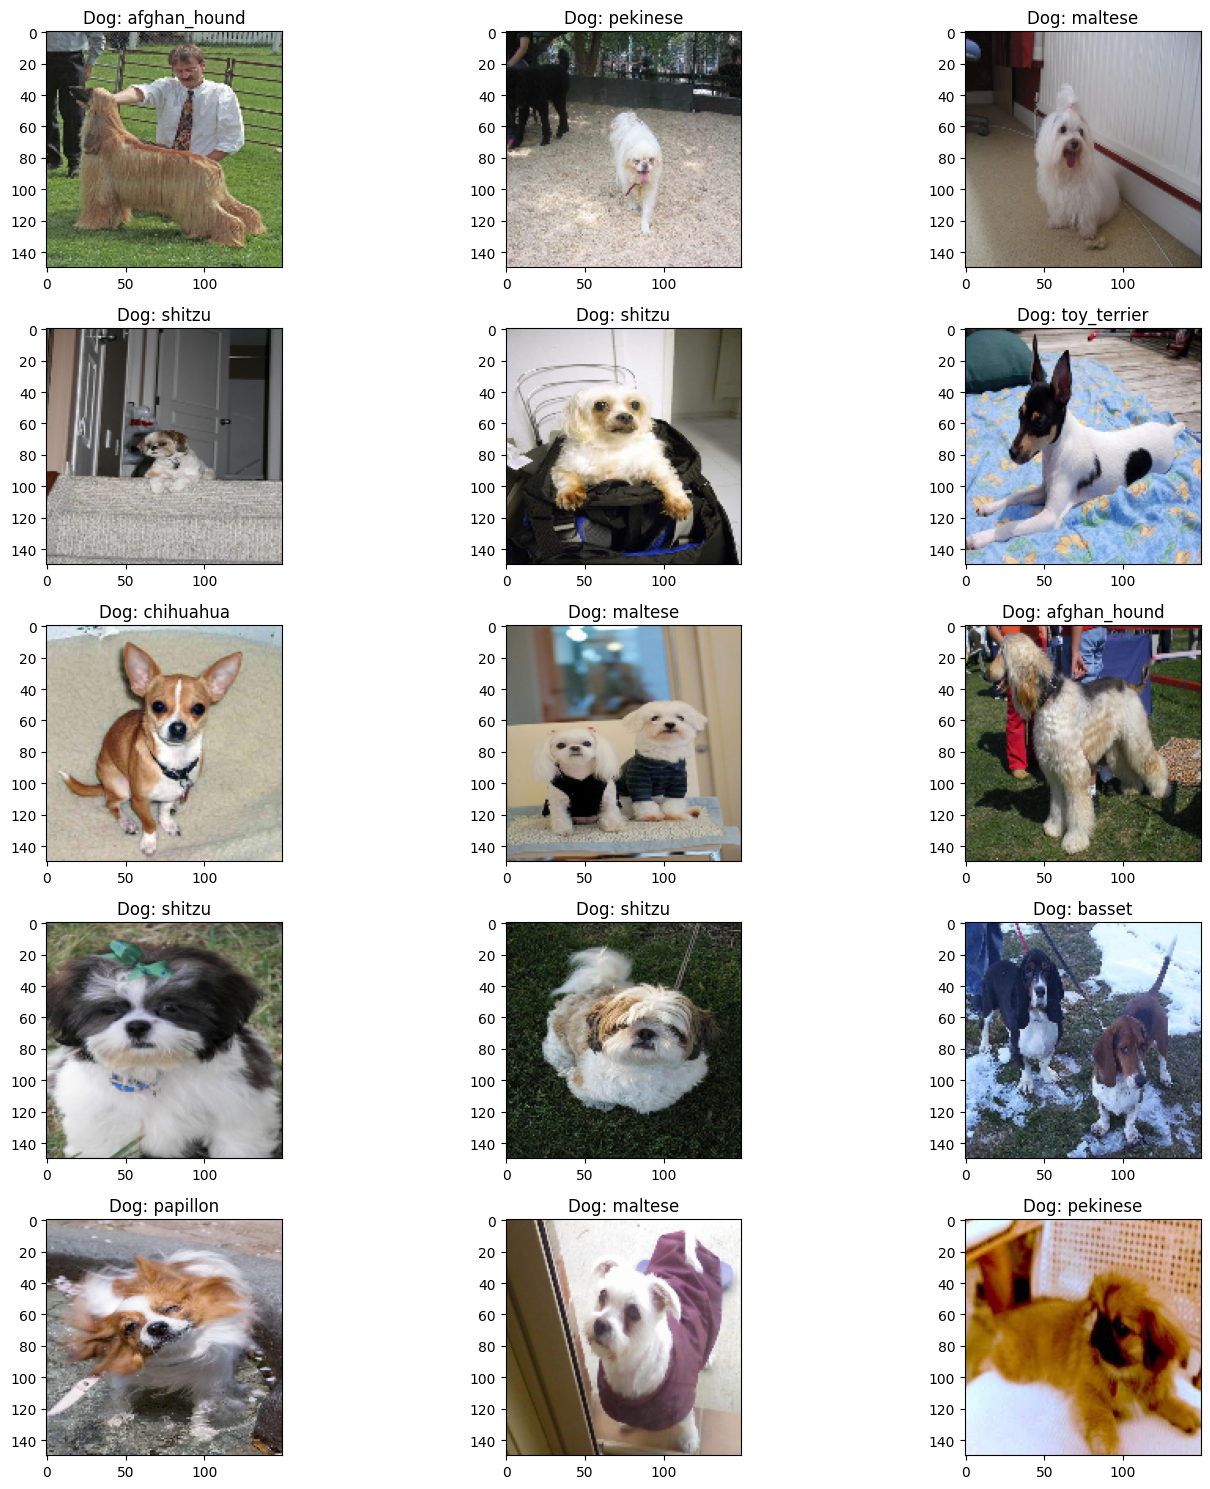

In [17]:
import matplotlib.pyplot as plt # 导入matplotlib
import random as rdm # 导入随机数工具
# 随机显示几张可爱的狗狗图片吧
fig,ax = plt.subplots(5,3)
fig.set_size_inches(15,15)
for i in range(5):
    for j in range (3):
        r = rdm.randint(0,len(X))
        X[r] = X[r][...,::-1] #将图像通道从BGR调整为RGB，防止色彩失真
        ax[i,j].imshow(X[r])
        ax[i,j].set_title('Dog: '+y_label[r])
plt.tight_layout()

In [18]:
from sklearn.model_selection import train_test_split # 导入拆分工具
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [12]:
from keras import layers # 导入所有层
from keras import models # 导入所有模型
cnn = models.Sequential() # 贯序模型
cnn.add(layers.Conv2D(32, (3, 3), activation='relu', # 卷积
                        input_shape=(150, 150, 3)))
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Conv2D(64, (3, 3), activation='relu')) # 卷积
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Conv2D(128, (3, 3), activation='relu')) # 卷积
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Conv2D(128, (3, 3), activation='relu')) # 卷积
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Flatten()) # 展平
cnn.add(layers.Dense(512, activation='relu')) # 全连接
cnn.add(layers.Dense(10, activation='softmax')) # 分类输出

cnn.compile(loss='categorical_crossentropy', # 损失函数
            optimizer='RMSprop', # 优化器
            metrics=['acc']) # 评估指标

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
history = cnn.fit(X_train,y_train, # 指定训练集
                    epochs=50,     # 指定轮次
                    batch_size=256, # 指定批量大小
                    validation_data=(X_test,y_test)) # 指定验证集

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - acc: 0.1132 - loss: 2.3032 - val_acc: 0.1195 - val_loss: 16.5397
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - acc: 0.1230 - loss: 4.5799 - val_acc: 0.0987 - val_loss: 2.3308
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step - acc: 0.1113 - loss: 2.2997 - val_acc: 0.0935 - val_loss: 2.3458
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - acc: 0.1178 - loss: 2.2878 - val_acc: 0.1065 - val_loss: 2.2896
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - acc: 0.1230 - loss: 2.2825 - val_acc: 0.1195 - val_loss: 2.3289
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - acc: 0.1340 - loss: 2.2694 - val_acc: 0.2182 - val_loss: 2.2791
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - acc: 0.1627 - loss: 2.2580 - val_acc: 0.0935 - val_loss: 2.6191
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - acc: 0.1327 - loss: 2.3232 - val_acc: 0.0961 - val_loss: 2.3134
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - acc: 0.1776 - loss: 2

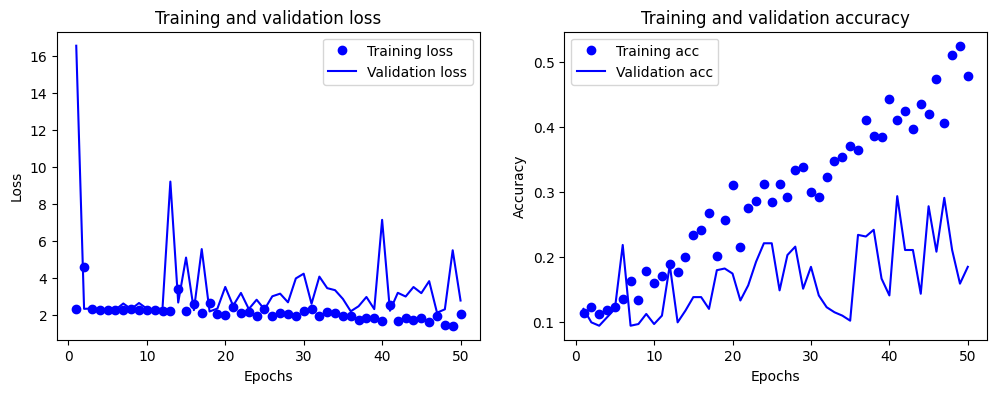

In [14]:
# 这段代码参考《Python深度学习》一书中的学习曲线的实现
def show_history(history): # 显示训练过程中的学习曲线
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.figure(figsize=(12,4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
show_history(history) # 调用这个函数，并将神经网络训练历史数据作为参数输入

In [19]:
from tensorflow.keras import optimizers # 导入优化器
cnn = models.Sequential() # 序贯模型
cnn.add(layers.Conv2D(32, (3, 3), activation='relu', # 卷积
                       input_shape=(150, 150, 3)))
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Conv2D(64, (3, 3), activation='relu')) # 卷积
cnn.add(layers.Dropout(0.5)) # Dropout
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Conv2D(128, (3, 3), activation='relu')) # 卷积
cnn.add(layers.Dropout(0.5)) # Dropout
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Conv2D(256, (3, 3), activation='relu')) # 卷积
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Flatten()) # 展平
cnn.add(layers.Dropout(0.5)) # Dropout
cnn.add(layers.Dense(512, activation='relu')) # 全连接
cnn.add(layers.Dense(10, activation='sigmoid')) # 分类输出

cnn.compile(loss='categorical_crossentropy', # 损失函数
            optimizer=optimizers.Adam(learning_rate=0.0001), # 更新优化器并设定学习速率
            metrics=['acc']) # 评估指标

history = cnn.fit(X_train,y_train, # 指定训练集
                  epochs=50,     # 指定轮次
                  batch_size=256, # 指定批量大小
                  validation_data=(X_test,y_test)) # 指定验证集

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - acc: 0.1126 - loss: 2.3294 - val_acc: 0.1325 - val_loss: 2.2924
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - acc: 0.1295 - loss: 2.2760 - val_acc: 0.1351 - val_loss: 2.2915
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - acc: 0.1379 - loss: 2.2542 - val_acc: 0.0883 - val_loss: 2.2898
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - acc: 0.1314 - loss: 2.2466 - val_acc: 0.1584 - val_loss: 2.2801
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 208ms/step - acc: 0.1542 - loss: 2.2292 - val_acc: 0.2026 - val_loss: 2.2669
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 211ms/step - acc: 0.1893 - loss: 2.1974 - val_acc: 0.2364 - val_loss: 2.2674
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/step - acc: 0.2056 - loss: 2.1774 - val_acc: 0.1532 - val_loss: 2.2636
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - acc: 0.2023 - loss: 2.1574 - val_acc: 0.2753 - val_loss: 2.2522
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - acc: 0.2134 - loss: 2.

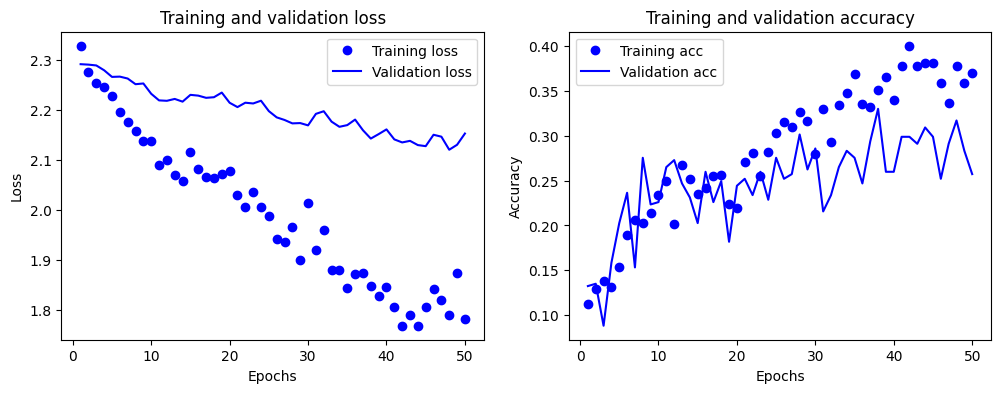

In [20]:
# 这段代码参考《Python深度学习》一书中的学习曲线的实现
def show_history(history): # 显示训练过程中的学习曲线
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.figure(figsize=(12,4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
show_history(history) # 调用这个函数，并将神经网络训练历史数据作为参数输入

In [21]:
cnn = models.Sequential() # 序贯模型
cnn.add(layers.Conv2D(32, (3, 3), activation='relu', # 卷积
                       input_shape=(150, 150, 3)))
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Conv2D(64, (3, 3), activation='relu')) # 卷积
cnn.add(layers.Dropout(0.5)) # Dropout
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Conv2D(128, (3, 3), activation='relu')) # 卷积
cnn.add(layers.Dropout(0.5)) # Dropout
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Conv2D(256, (3, 3), activation='relu')) # 卷积
cnn.add(layers.MaxPooling2D((2, 2))) # 最大池化
cnn.add(layers.Flatten()) # 展平
cnn.add(layers.Dropout(0.5)) # Dropout
cnn.add(layers.Dense(512, activation='relu')) # 全连接
cnn.add(layers.Dense(10, activation='sigmoid')) # 分类输出

cnn.compile(loss='categorical_crossentropy', # 损失函数
            optimizer=optimizers.Adam(learning_rate=1e-4), # 更新优化器并设定学习速率
            metrics=['acc']) # 评估指标

history = cnn.fit(X_train,y_train, # 指定训练集
                  epochs=50,     # 指定轮次
                  batch_size=256, # 指定批量大小
                  validation_data=(X_test,y_test)) # 指定验证集

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - acc: 0.1230 - loss: 2.3237 - val_acc: 0.1532 - val_loss: 2.2948
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 212ms/step - acc: 0.1509 - loss: 2.2770 - val_acc: 0.2052 - val_loss: 2.2910
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step - acc: 0.1809 - loss: 2.2612 - val_acc: 0.1377 - val_loss: 2.2898
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - acc: 0.1418 - loss: 2.2544 - val_acc: 0.2182 - val_loss: 2.2824
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - acc: 0.2043 - loss: 2.2241 - val_acc: 0.1506 - val_loss: 2.2797
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step - acc: 0.1457 - loss: 2.2336 - val_acc: 0.1325 - val_loss: 2.2757
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - acc: 0.1841 - loss: 2.2067 - val_acc: 0.1948 - val_loss: 2.2727
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 223ms/step - acc: 0.1418 - loss: 2.2246 - val_acc: 0.2494 - val_loss: 2.2681
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - acc: 0.2147 - loss: 2.

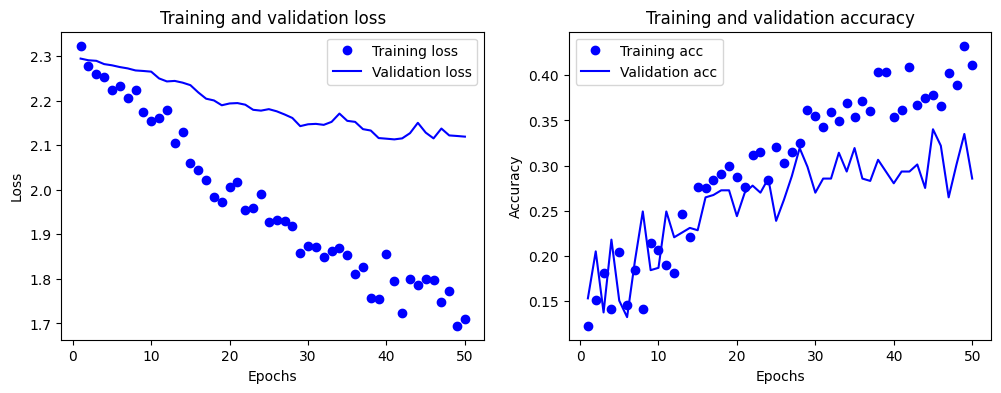

In [22]:
# 这段代码参考《Python深度学习》一书中的学习曲线的实现
def show_history(history): # 显示训练过程中的学习曲线
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.figure(figsize=(12,4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
show_history(history) # 调用这个函数，并将神经网络训练历史数据作为参数输入

In [23]:
# 定义一个数据增强器，并设定各种增强选项
from tensorflow.keras.preprocessing.image import ImageDataGenerator
augs_gen = ImageDataGenerator(
           featurewise_center=False,
           samplewise_center=False,
           featurewise_std_normalization=False,
           samplewise_std_normalization=False,
           zca_whitening=False,
           rotation_range=10,
           zoom_range = 0.1,
           width_shift_range=0.2,
           height_shift_range=0.2,
           horizontal_flip=True,
           vertical_flip=False)
augs_gen.fit(X_train) # 针对训练集拟合数据增强器

In [24]:
history = cnn.fit( # 使用fit_generator
    augs_gen.flow(X_train,y_train,batch_size=16), # 增强后的训练集
    validation_data = (X_test,y_test), # 指定验证集
    epochs = 50,  # 指定轮次
    verbose = 1) # 指定是否显示训练过程中的信息

Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 22s 154ms/step - acc: 0.2778 - loss: 2.0702 - val_acc: 0.3013 - val_loss: 2.1348
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - acc: 0.2804 - loss: 2.0264 - val_acc: 0.2623 - val_loss: 2.1484
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - acc: 0.2876 - loss: 1.9906 - val_acc: 0.3584 - val_loss: 2.1115
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - acc: 0.3006 - loss: 1.9620 - val_acc: 0.3403 - val_loss: 2.0930
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - acc: 0.3299 - loss: 1.9412 - val_acc: 0.3429 - val_loss: 2.1143
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - acc: 0.3182 - loss: 1.9458 - val_acc: 0.3688 - val_loss: 2.0790
Epoch 7/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - acc: 0.3455 - loss: 1.8786 - val_acc: 0.2961 - val_loss: 2.1049
Epoch 8/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - acc: 0.3637 - loss: 1.8427 - val_acc: 0.3532 - val_loss: 2.0603
Epoch 9/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - 

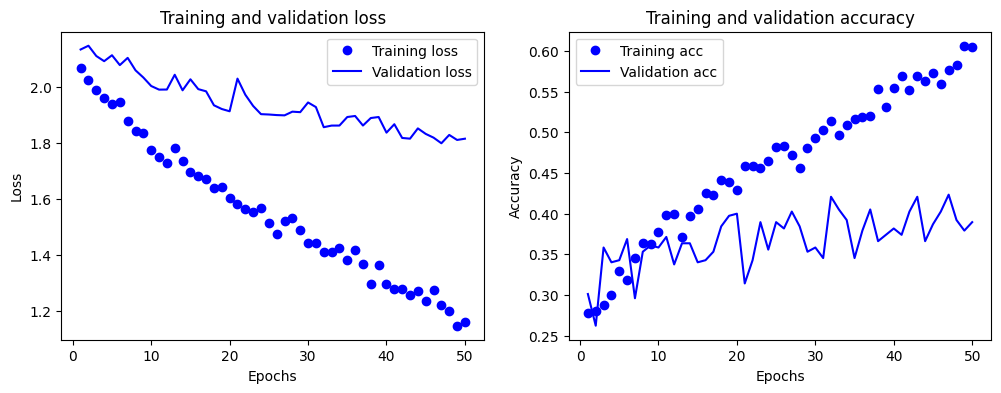

In [25]:
# 这段代码参考《Python深度学习》一书中的学习曲线的实现
def show_history(history): # 显示训练过程中的学习曲线
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.figure(figsize=(12,4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
show_history(history) # 调用这个函数，并将神经网络训练历史数据作为参数输入

In [26]:
from keras.models import load_model # 导入模型保存工具
cnn.save('../my_dog_cnn.h5')  # 创建一个HDF5格式的文件'my_dog_cnn.h5'
del cnn  # 删除当前模型
cnn = load_model('../my_dog_cnn.h5') # 重新载入已经保存的模型

In [27]:
import os
from tensorflow.keras.models import load_model # 更加稳健的导入方式

# 直接保存在当前 /content 目录下，方便在左侧文件夹面板直接看到
model_path = 'my_dog_cnn.keras'

# 保存模型
cnn.save(model_path)
print(f"模型已成功保存至: {os.path.abspath(model_path)}")

# 删除内存中的模型对象（手动回收内存）
del cnn

# 重新载入模型
# compile=True 会同时载入你之前训练时的 Adam 优化器和 Loss 函数状态
cnn = load_model(model_path, compile=True)

print("模型已成功重新载入！")
# 查看模型结构确认载入无误
cnn.summary()

模型已成功保存至: /content/my_dog_cnn.keras
模型已成功重新载入！


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 72, 72, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 34, 34, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,449,760 (78.01 MB)

 Trainable params: 6,816,586 (26.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,633,174 (52.01 MB)

In [28]:
from google.colab import files
files.download('my_dog_cnn.keras') # 运行这行，模型就会存入你电脑的“下载”文件夹

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step


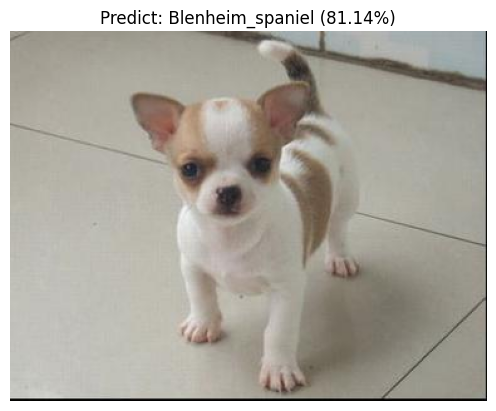

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# 1. 载入模型（确保文件名一致）
model = load_model('my_dog_cnn.keras')

# 2. 读取并预处理图片
def prepare_image(image_path):
    img_size = 150 # 必须和你训练时的尺寸一模一样
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # 转回 RGB 方便显示
    img = cv2.resize(img, (img_size, img_size)) # 缩放
    img = img / 255.0 # 归一化（这是模型最喜欢的“食物”格式）
    return np.expand_dims(img, axis=0) # 关键：增加 batch 维度，变成 (1, 150, 150, 3)

# 3. 开始预测
image_path = 'test_dog.jpg' # 你的图片文件名
input_img = prepare_image(image_path)
prediction = model.predict(input_img)

# 4. 获取结果
predicted_class_idx = np.argmax(prediction) # 找到概率最大的索引
confidence = np.max(prediction) * 100 # 看看模型有多自信

# 5. 显示结果
# 注意：这里的 labels 顺序必须和你训练时 training_data 调用的顺序完全一致
labels = ['Chihuahua', 'Japanese_spaniel', 'Maltese_dog', 'Pekinese', 'Shih-Tzu',
          'Blenheim_spaniel', 'Papillon', 'Toy_terrier', 'Rhodesian_ridgeback', 'Afghan_hound']

plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.title(f"Predict: {labels[predicted_class_idx]} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

In [35]:
import shutil

# 参数1：压缩后的文件名（不用带.zip）
# 参数2：压缩格式 'zip'
# 参数3：你要下载的那个文件夹路径
shutil.make_archive('my_dogs_data', 'zip', 'stanford_dogs')

print("压缩完成")


压缩完成


In [34]:
files.download('my_dogs_data.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>